# Pythonprogrammering och AI strategi, möjligheter och utmaningar
## Kunskapskontroll - EDA

I denna kunskapskontroll ska jag göra en EDA. Jag besvarar följande diskussionsfrågor på slutet. Dom bifogas även i ett eget dokument via GitHub.

1. Har något varit utmanande i kursen/kunskapskontrollerna? Om ja, hur har du hanterat det? Vilka lärdomar tar du med dig till framtida kurser?
2. Vilket betyg anser du att du ska ha och varför?
3. Något du vill lyfta fram till Terese?

==========================================================================================

# Exploratory Data Analysis (EDA) - Housing Dataset
I denna analys undersöker jag bostadsdata för att identifiera mönster som påverkar prissättningen. Jag kommer att eller i alla fall försöka, titta på korrelationer, hantera saknade värden och visualisera fördelningen av priser.

Vi kommer att gå igenom följande steg:
1. Datainspektion och rengöring.
2. Deskriptiv statistik.
3. Visualisering av fördelningar och samband.
4. Slutsatser om prissättning.
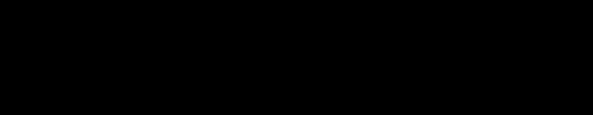
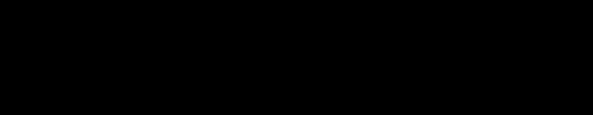

Index(['longitud', 'latitud', 'husets_ålder_median', 'antal_rum_totalt',
       'antal_sovrum_totalt', 'befolkning', 'hushåll', 'medianinkomst',
       'huspris_median', 'närhet_till_havet'],
      dtype='str')
Datasetet laddades
Index(['longitud', 'latitud', 'husets_ålder_median', 'antal_rum_totalt',
       'antal_sovrum_totalt', 'befolkning', 'hushåll', 'medianinkomst',
       'huspris_median', 'närhet_till_havet'],
      dtype='str')


## 1. Datainspektion och rengöring
Innan analysen kollar jag efter saknade värden och efter ev felaktiga/konstiga data.

In [55]:
# Kimport pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# 1. Ladda datan
try:
    df = pd.read_csv('data/housing.csv')
    print("1. Datasetet laddades")
except FileNotFoundError:
    print("Kunde inte hitta filen. Kontrollera att den ligger i mappen 'data'.")

# 2. DEFINIERA OCH DÖP OM KOLUMNER
namn_mapping = {
    'longitude': 'longitud',
    'latitude': 'latitud',
    'housing_median_age': 'husets_ålder_median',
    'total_rooms': 'antal_rum_totalt',
    'total_bedrooms': 'antal_sovrum_totalt',
    'population': 'befolkning',
    'households': 'hushåll',
    'median_income': 'medianinkomst',
    'median_house_value': 'huspris_median',
    'ocean_proximity': 'närhet_till_havet'
}

df.rename(columns=namn_mapping, inplace=True)

# 3. KONTROLLERA RESULTATET SIST
print("\n2. Nu heter kolumnerna följande:")
print(df.columns)

# Visa de första raderna för att se att datan ser rätt ut
df.head()

1. Datasetet laddades

2. Nu heter kolumnerna följande:
Index(['longitud', 'latitud', 'husets_ålder_median', 'antal_rum_totalt',
       'antal_sovrum_totalt', 'befolkning', 'hushåll', 'medianinkomst',
       'huspris_median', 'närhet_till_havet'],
      dtype='str')


,longitud,latitud,husets_ålder_median,antal_rum_totalt,antal_sovrum_totalt,befolkning,hushåll,medianinkomst,huspris_median,närhet_till_havet
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## 2. Statistisk sammanfattning
Vi tittar på de centrala måtten för att få en överblick av prisspannet och husens storlek.

In [31]:
# Deskriptiv statistik för numeriska kolumner
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


## 3. Visualiseringar
### Prisfördelning
Vi börjar med att titta på hur priserna är fördelade. Är de flesta husen billiga, eller finns det många lyxvillor?

Text(0.5, 0, 'Medianpris (USD)')

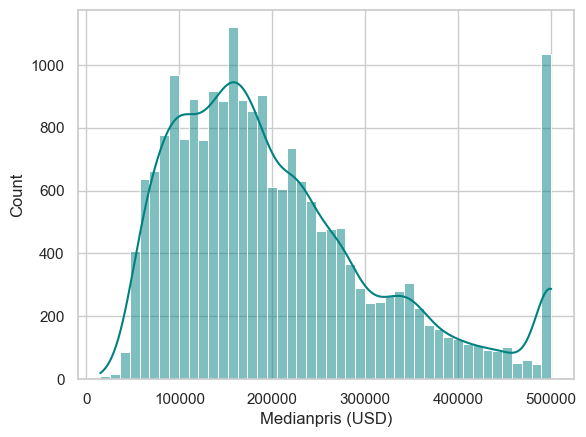

In [52]:
sns.histplot(df['huspris_median'], kde=True, color='teal')
plt.xlabel('Medianpris (USD)')

### Samband mellan Area och Pris
Här undersöker vi om större hus alltid innebär ett högre pris. Vi använder ett scatter-plot för att se trenden.

Text(0, 0.5, 'Medianpris')

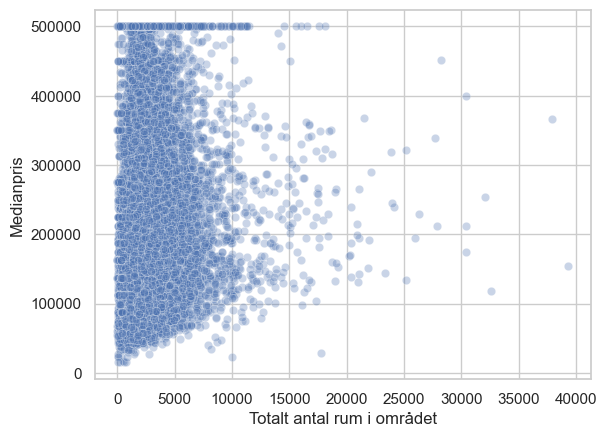

In [53]:
sns.scatterplot(data=df, x='antal_rum_totalt', y='huspris_median', alpha=0.3)
plt.xlabel('Totalt antal rum i området')
plt.ylabel('Medianpris')

### Korrelationsmatris
Vilka variabler har starkast koppling till varandra? En heatmap ger oss svaret snabbt.

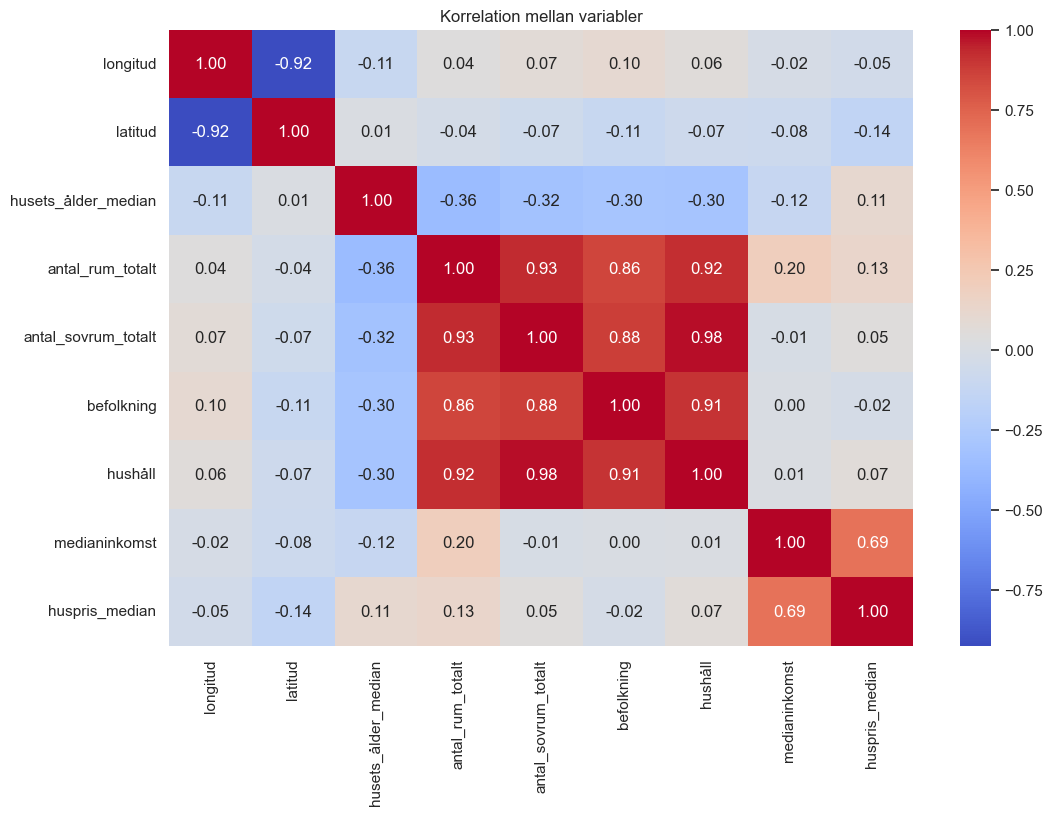

In [54]:
plt.figure(figsize=(12, 8))
# Vi korrelerar endast numeriska värden
correlation_matrix = df.select_dtypes(include=['number']).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Korrelation mellan variabler')
plt.show()

## 4. Slutsatser
Baserat på analysen ovan kan vi dra följande slutsatser:
* **Saknade värden:** (Fyll i om du hittade några och hur du hanterade dem).
* **Dyrast/Billigast:** Hus med större area och fler rum tenderar att vara dyrare, vilket syns tydligt i korrelationsmatrisen. Detta är ju inget konstigt utan egentligen självklarheter.
* **Viktigaste faktor:** (Här skriver du vilken kolumn som hade högst korrelation med priset).

## Självutvärdering:

1. Har något varit utmanande i kursen/kunskapskontrollerna? Om ja, hur har du hanterat det? Vilka lärdomar tar du med dig till framtida kurser?
sdsdf

1. Vilket betyg anser du att du ska ha och varför?
asfasf

1. Något du vill lyfta fram till Teres
sdf sd f